# Tracing the band-split type II burst in the combined I-LOFAR + ORFEES spectrum

**Event:** 2025-10-06, ~08:57-09:02 UT, ~130-280 MHz (band-split type II seen by
both I-LOFAR REALTA and ORFEES).

This notebook

1. loads the ORFEES and I-LOFAR dynamic spectra;
2. **downsamples I-LOFAR to the ORFEES cadence** (I-LOFAR is the finer instrument),
   background-subtracts, drops the ORFEES channels that overlap the I-LOFAR bands
   (I-LOFAR is kept where they overlap), and normalises the two together so the whole
   combined spectrum sits in [0, 1] **jointly**;
3. lets you **click** the spectrum to trace the type II. Because the burst is
   band-split you trace the **upper** and **lower** lane of the **fundamental (F)**
   and **harmonic (H)** bands separately;
4. for each band pairs the nearest-in-time upper/lower points to get the
   **density jump** $X=(f_U/f_L)^2$ and the **instantaneous bandwidth**;
5. **right-click resets** the plot for a fresh pass while keeping earlier passes,
   repeated **5 times** to get a standard error;
6. applies **all four coronal density models** (Newkirk, Saito, Leblanc, Mann 2023)
   each at **fold 1, 2, 3, 4** to convert frequency to source height $r/R_\odot$;
7. produces a **4-panel figure** (height, speed, acceleration vs time, and $B$ vs
   height *and* time) with error bars and a Savitzky-Golay smoothed curve;
8. exports the figures (PNG + PDF), the characteristics table (CSV + LaTeX) and a
   pickle of the raw picks.

**Physics.** With harmonic number $s$ ($s{=}1$ fundamental, $s{=}2$ harmonic),
$N_e=\left(\tfrac{f_{\rm obs}/s}{8.98\times10^3}\right)^2\,{\rm cm^{-3}}$ and
$X\equiv N_{\rm down}/N_{\rm up}=(f_U/f_L)^2$ (independent of $s$). For a low-$\beta$
perpendicular shock ($\gamma=5/3$), $M_A^2=\dfrac{X(X+5)}{2(4-X)}$, and with the
shock speed from the height-time gradient of the **lower** (upstream) band,
$v_A=v_{\rm sh}/M_A$, $B=v_A\sqrt{\mu_0\rho}$, $\rho=\mu m_p N_e$
(Smerd 1974; Vrsnak 2002, 2004; Gopalswamy 2012; Vasanth 2014).

In [26]:
import warnings
warnings.filterwarnings('ignore')
import os, glob, pickle
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.lines import Line2D
from datetime import datetime
from tqdm.auto import tqdm
import astropy.units as u
from astropy.time import Time
from astropy.io import fits as pyfits
from astropy.constants import R_sun
from scipy.optimize import brentq
from scipy.signal import savgol_filter
from scipy.interpolate import interp1d
from scipy.constants import m_p, mu_0, e as E_CHARGE, epsilon_0, m_e
from sunpy.net import attrs as sunpy_attrs
from radiospectra.spectrogram import Spectrogram
from sigpyproc.readers import FilReader

mpl.rcParams['date.epoch'] = '1970-01-01T00:00:00'
try:
    mdates.set_epoch('1970-01-01T00:00:00')
except Exception:
    pass
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['savefig.facecolor'] = 'white'

In [27]:
# ---- configuration (edit paths/dates here) ------------------------
DATA_ROOT       = '/home/mnedal/data'                # DIAS machine
ILOFAR_PATH     = f'{DATA_ROOT}/I-LOFAR'
ORFEES_PATH     = f'{DATA_ROOT}/ORFEES'
STOKES          = 'I'
ILOFAR_SOURCE   = 'pickle'                           # 'raw' -> read the .fil ; 'pickle' -> load saved dataframes
ILOFAR_DATETIME = '2025-10-06T08:50:00'              # timestamp embedded in the .fil filename
PICKLE_TAG      = '20251006'                         # tag used for the I-LOFAR pickle filenames
SAVE_PICKLES    = True                               # when reading raw, also write pickles for faster reloads
MYDATE          = '2025-10-06'                       # ORFEES fits date
EVENT_START     = pd.Timestamp('2025-10-06 08:57:00')
EVENT_END       = pd.Timestamp('2025-10-06 09:02:00')
NORMALISE_COMBINED = False    # True -> joint [0,1]-normalised combined spectrum ;
                              # False -> per-instrument display limits (no normalisation)
N_PASSES        = 5
REF_MODEL_NAME  = 'Newkirk x2'                       # model+fold shown in the 4-panel figure
MU              = 1.27                               # mean molecular weight per electron (1.17 for a 10% He corona)
OUTDIR          = './type2_outputs'
os.makedirs(OUTDIR, exist_ok=True)

# physical constants from libraries (no hardcoding)
R_SUN_M      = R_sun.to('m').value                                          # solar radius [m]
# electron plasma frequency: f_p[Hz] = PLASMA_CONST * sqrt(Ne[cm^-3])
PLASMA_CONST = (1 / (2 * np.pi)) * np.sqrt(1e6 * E_CHARGE ** 2 / (epsilon_0 * m_e))

## 1. Load the two dynamic spectra

In [28]:
# --- I-LOFAR: raw .fil (with progress bar) or saved pickles, controlled by ILOFAR_SOURCE ---
def get_ilofar_file(paths, dt):
    for p in paths:
        try:
            if p.split('_')[1] == dt:
                return p
        except IndexError:
            continue
    return None

def freq_axis(freqs):
    # re-insert the REALTA mode gaps into the frequency axis
    gap1 = np.flipud(freqs[288] + (np.arange(59) * 0.390625))
    gap2 = np.flipud(freqs[88]  + (np.arange(57) * 0.390625))
    ax_shape = 59 + 57 - 1
    new_freq = np.zeros(ax_shape + freqs.shape[0])
    new_freq[0:88]    = freqs[0:88]
    new_freq[88:145]  = gap2[:57]
    new_freq[145:345] = freqs[88:288]
    new_freq[345:404] = gap1[:59]
    new_freq[404:]    = freqs[289:]
    return new_freq

freq_mode3 = np.linspace(10, 90, 199)     # 10-90 MHz
freq_mode5 = np.linspace(110, 190, 200)   # 110-190 MHz
freq_mode7 = np.linspace(210, 270, 88)    # 210-270 MHz

if ILOFAR_SOURCE == 'pickle':
    df_mode3 = pd.read_pickle(f'{ILOFAR_PATH}/df_mode3_realta_{PICKLE_TAG}_S{STOKES}.pkl')
    df_mode5 = pd.read_pickle(f'{ILOFAR_PATH}/df_mode5_realta_{PICKLE_TAG}_S{STOKES}.pkl')
    df_mode7 = pd.read_pickle(f'{ILOFAR_PATH}/df_mode7_realta_{PICKLE_TAG}_S{STOKES}.pkl')
    print('Loaded I-LOFAR dataframes from pickles.')
else:
    filename = get_ilofar_file(sorted(glob.glob(f'{ILOFAR_PATH}/*.fil')), ILOFAR_DATETIME)
    print('Reading I-LOFAR file:', filename)
    a      = FilReader(filename)
    hdr    = a.header
    tstart = Time(hdr.tstart, format='mjd')
    tsamp  = hdr.tsamp
    freqs  = np.asarray(hdr.chan_freqs)
    nsamp  = hdr.nsamples

    # read the (large) block in time chunks so the disk read shows a progress bar
    CHUNK = 200000
    parts = []
    for start in tqdm(range(0, nsamp, CHUNK), desc='Reading .fil'):
        ns = min(CHUNK, nsamp - start)
        parts.append(np.asarray(a.read_block(start=start, nsamps=ns), dtype=float))
    raw = np.hstack(parts)
    del parts
    nt = raw.shape[1]

    with np.errstate(divide='ignore'):
        raw = np.log10(raw)
    raw[np.isinf(raw)] = 0.0

    new_freq = freq_axis(freqs)
    data2 = np.full((new_freq.shape[0], nt), np.nan)
    data2[0:88]    = raw[0:88]
    data2[145:345] = raw[88:288]
    data2[404:]    = raw[289:]
    del raw

    # vectorised time axis (no per-sample Time->iso conversion)
    Tarray = pd.Timestamp(tstart.to_datetime()) + pd.to_timedelta(np.arange(nt) * tsamp, unit='s')
    df_mode3 = pd.DataFrame(data2[404:].T,    columns=freq_mode3[::-1], index=Tarray)
    df_mode5 = pd.DataFrame(data2[145:345].T, columns=freq_mode5[::-1], index=Tarray)
    df_mode7 = pd.DataFrame(data2[:88].T,     columns=freq_mode7[::-1], index=Tarray)
    del data2

    if SAVE_PICKLES:
        df_mode3.to_pickle(f'{ILOFAR_PATH}/df_mode3_realta_{PICKLE_TAG}_S{STOKES}.pkl')
        df_mode5.to_pickle(f'{ILOFAR_PATH}/df_mode5_realta_{PICKLE_TAG}_S{STOKES}.pkl')
        df_mode7.to_pickle(f'{ILOFAR_PATH}/df_mode7_realta_{PICKLE_TAG}_S{STOKES}.pkl')
        print('Saved pickles (set ILOFAR_SOURCE to pickle next time for a fast reload).')

print('I-LOFAR mode5', df_mode5.shape, ' mode7', df_mode7.shape)

Loaded I-LOFAR dataframes from pickles.
I-LOFAR mode5 (3204346, 200)  mode7 (3204346, 88)


In [29]:
# --- ORFEES: loaded exactly as in the source notebook (via radiospectra Spectrogram) ---
year, month, day = MYDATE.split('-')
files = sorted(glob.glob(f'{ORFEES_PATH}/*{year}{month}{day}_*.fts'))
print(*files, sep='\n')

orfees   = pyfits.open(files[0])
orfees_i = np.hstack([orfees[2].data[f'STOKESI_B{i}'] for i in range(1, 6)]).T
data     = orfees_i.T

# background subtraction (subtract the temporal mean per channel)
new_data = data - np.tile(np.nanmean(data, 0), (data.shape[0], 1))
new_data = new_data.T

orfees_time_str = orfees[0].header['DATE-OBS']
orfees_times = Time(orfees_time_str) + (orfees[2].data['TIME_B1'] / 1000) * u.s
orfees_freqs = np.hstack([orfees[1].data[f'FREQ_B{i}'] for i in range(1, 6)]) * u.MHz

orfees_meta = {
    'observatory': orfees[0].header['ORIGIN'],
    'instrument' : orfees[0].header['INSTRUME'],
    'detector'   : orfees[0].header['INSTRUME'],
    'freqs'      : orfees_freqs.reshape(-1),
    'times'      : orfees_times,
    'wavelength' : sunpy_attrs.Wavelength(orfees_freqs[0, 0], orfees_freqs[0, -1]),
    'start_time' : orfees_times[0],
    'end_time'   : orfees_times[-1]
}
orfees_spec_i = Spectrogram(new_data, orfees_meta)

orf_times = pd.to_datetime(orfees_spec_i.times.datetime)
orf_freqs = orfees_spec_i.frequencies.value          # MHz, 1-D
orf_data  = orfees_spec_i.data                        # (freq, time), background-subtracted
orf_dt_ms = float(np.median(np.diff(orf_times.values)) / np.timedelta64(1, 'ms'))
print('ORFEES', orf_data.shape, f'{orf_freqs.min():.0f}-{orf_freqs.max():.0f} MHz',
      f'| native cadence ~ {orf_dt_ms:.0f} ms')

/home/mnedal/data/ORFEES/int_orf20251006_085500_0.1.fts
ORFEES (998, 6000) 144-1005 MHz | native cadence ~ 100 ms


## 2. Downsample I-LOFAR to the ORFEES cadence and build the combined layers

In [30]:
def robust_limits(arr, lo=5, hi=99):
    # per-instrument display limits, as in the source notebook
    v = np.asarray(arr).ravel()
    return np.nanpercentile(v, lo), np.nanpercentile(v, hi)

# I-LOFAR is the finer instrument, so it is the one downsampled -> ORFEES cadence
ORFEES_CADENCE = f'{orf_dt_ms:.0f}ms'
print('resampling I-LOFAR to', ORFEES_CADENCE)

def prep_ilofar(df):
    # slice to the event, downsample to the ORFEES cadence, background-subtract per channel
    d = df.loc[EVENT_START:EVENT_END].resample(ORFEES_CADENCE).mean()
    arr = d.values.astype(float)
    arr = arr - np.nanmean(arr, axis=0, keepdims=True)
    return d.index, d.columns.values.astype(float), arr.T     # times, freqs, (freq, time)

t5, f5, D5 = prep_ilofar(df_mode5)     # 110-190 MHz
t7, f7, D7 = prep_ilofar(df_mode7)     # 210-270 MHz

# keep I-LOFAR where the two instruments overlap: drop the ORFEES channels inside the
# I-LOFAR bands (I-LOFAR has the finer frequency resolution there)
IL_BANDS = [(110, 190), (210, 270)]
keep = np.ones(orf_freqs.shape, bool)
for lo_b, hi_b in IL_BANDS:
    keep = keep & ~((orf_freqs >= lo_b) & (orf_freqs <= hi_b))
of = orf_freqs[keep]
Do = orf_data[keep]

# --- joint normalisation into a single [0,1] range for the WHOLE combined spectrum ---
# I-LOFAR (log-power) and ORFEES (linear counts) record in different units, so a plain
# pooled min-max lets one instrument's scale swamp the other. Put both on a common
# footing first (per-instrument z-score), then apply ONE shared [0,1] mapping to the pool.
def zscore(x):
    return (x - np.nanmean(x)) / np.nanstd(x)

Z5, Z7, Zo = zscore(D5), zscore(D7), zscore(Do)
z_lo, z_hi = np.nanpercentile(np.concatenate([Z5.ravel(), Z7.ravel(), Zo.ravel()]), [2, 99])
def joint_norm(z):
    return np.clip((z - z_lo) / (z_hi - z_lo), 0, 1)

# each layer carries its raw values AND the jointly-normalised copy
layers = [
    {'name': 'I-LOFAR mode5', 't': t5,       'f': f5, 'raw': D5, 'norm': joint_norm(Z5)},
    {'name': 'I-LOFAR mode7', 't': t7,       'f': f7, 'raw': D7, 'norm': joint_norm(Z7)},
    {'name': 'ORFEES',        't': orf_times, 'f': of, 'raw': Do, 'norm': joint_norm(Zo)},
]

def _plot_spec(ax, t, f, D, vmin, vmax):
    # plot a (freq, time) block, splitting at frequency gaps so pcolormesh never bridges
    # an excised band (a bridge would paint a false quad over the other instrument)
    f = np.asarray(f, float)
    order = np.argsort(f)
    fs = f[order]
    Ds = np.asarray(D)[order]
    dfreq = np.diff(fs)
    med = np.median(dfreq)
    breaks = np.where(dfreq > 3 * med)[0] + 1
    for seg in np.split(np.arange(fs.size), breaks):
        if seg.size < 2:
            continue
        ax.pcolormesh(t, fs[seg], Ds[seg], cmap='RdYlBu_r',
                      vmin=vmin, vmax=vmax, shading='auto')

def draw_layers(ax, normalise=None):
    # plot every layer on one axis; joint [0,1] scale if normalise else per-instrument limits
    if normalise is None:
        normalise = NORMALISE_COMBINED
    for L in layers:
        if normalise:
            _plot_spec(ax, L['t'], L['f'], L['norm'], 0, 1)
        else:
            vmin, vmax = robust_limits(L['raw'])
            _plot_spec(ax, L['t'], L['f'], L['raw'], vmin, vmax)

print('combined layers:', [(L['name'], L['norm'].shape) for L in layers])

resampling I-LOFAR to 100ms
combined layers: [('I-LOFAR mode5', (200, 3001)), ('I-LOFAR mode7', (88, 3001)), ('ORFEES', (734, 6000))]


### I-LOFAR spectrum (downsampled to the ORFEES cadence)

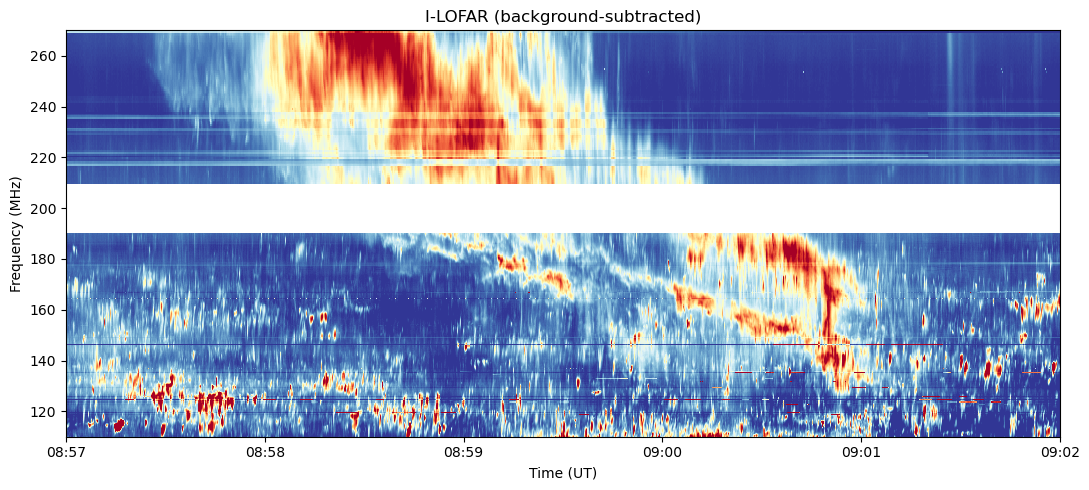

In [38]:
fig, ax = plt.subplots(figsize=[11, 5])
for t, f, D in [(t5, f5, D5), (t7, f7, D7)]:
    vmin, vmax = robust_limits(D)
    ax.pcolormesh(t, f, D, cmap='RdYlBu_r', vmin=vmin, vmax=vmax, shading='auto')
ax.set_ylim(110, 270)
ax.set_xlim(EVENT_START, EVENT_END)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax.set_xlabel('Time (UT)')
ax.set_ylabel('Frequency (MHz)')
ax.set_title('I-LOFAR (background-subtracted)')
fig.tight_layout()
plt.show()

In [40]:
print(f5[0], f5[-1])
print(f7[0], f7[-1])
print(orf_freqs[0], orf_freqs[-1])

190.0 110.0
270.0 210.0
144.13 1004.7


### ORFEES spectrum

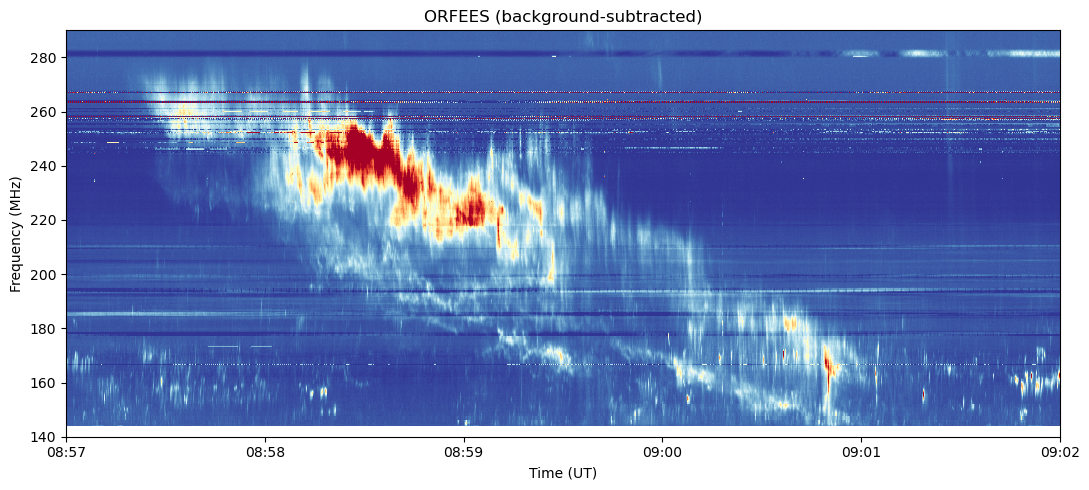

In [32]:
fig, ax = plt.subplots(figsize=[11, 5])
vmin, vmax = robust_limits(orf_data, 5, 98.7)
ax.pcolormesh(orf_times, orf_freqs, orf_data, cmap='RdYlBu_r',
              vmin=vmin, vmax=vmax, shading='auto')
ax.set_ylim(140, 290)
ax.set_xlim(EVENT_START, EVENT_END)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax.set_xlabel('Time (UT)')
ax.set_ylabel('Frequency (MHz)')
ax.set_title('ORFEES (background-subtracted)')
fig.tight_layout()
plt.show()

### Combined spectrum (normalisation controlled by `NORMALISE_COMBINED`)

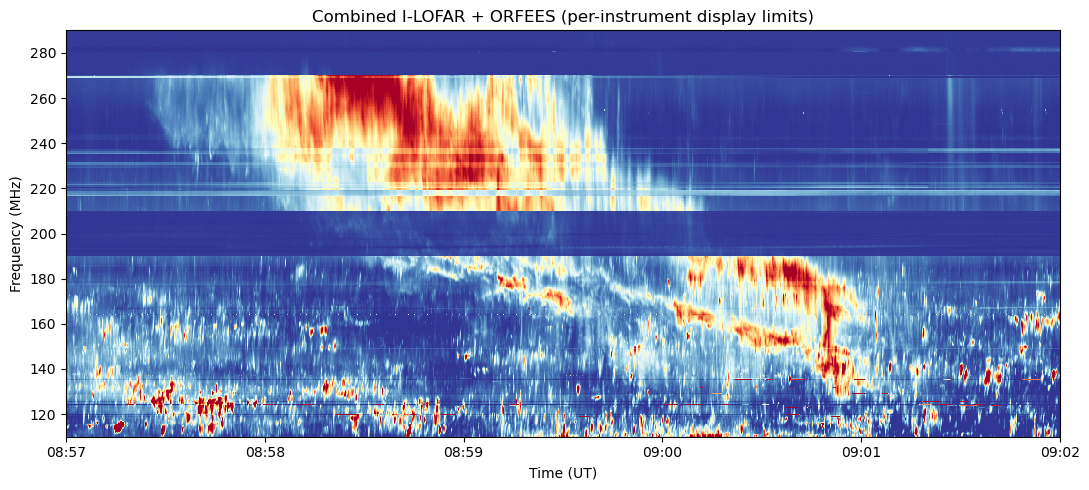

In [33]:
fig, ax = plt.subplots(figsize=[11, 5])
draw_layers(ax)
ax.set_ylim(110, 290)
ax.set_xlim(EVENT_START, EVENT_END)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax.set_xlabel('Time (UT)')
ax.set_ylabel('Frequency (MHz)')
tag = 'jointly normalised to [0,1]' if NORMALISE_COMBINED else 'per-instrument display limits'
ax.set_title(f'Combined I-LOFAR + ORFEES ({tag})')
fig.tight_layout()
plt.show()

## 3. Coronal electron-density models (each usable at fold 1, 2, 3, 4)

In [41]:
def newkirk(r, fold=1):
    r = np.asarray(r, float)
    return fold * 4.2e4 * 10.0 ** (4.32 / r)

def saito(r, fold=1, region='equatorial'):
    r = np.asarray(r, float)
    a1, b1, a2, b2 = (1.36e6, 2.14, 1.68e8, 6.13) if region == 'equatorial' \
                     else (2.5e5, 2.5, 1.0e8, 6.0)
    return fold * (a1 * r ** (-b1) + a2 * r ** (-b2))

def leblanc(r, fold=1):
    r = np.asarray(r, float)
    return fold * (3.3e5 / r ** 2 + 4.1e6 / r ** 4 + 8.0e7 / r ** 6)

_MANN_R  = np.array([1.0,1.1,1.2,1.3,1.4,1.5,1.6,1.8,2.0,2.5,3.0,4.0,5.0,6.0,8.0,
    10.0,12.0,14.0,16.0,20.0,25.0,30.0,40.0,50.0,60.0,70.0,80.0,100.0,120.0,
    160.0,200.0,215.0,250.0])
_MANN_NE = np.array([7.17e8,2.60e8,1.12e8,5.46e7,2.96e7,1.74e7,1.09e7,5.02e6,
    2.69e6,8.58e5,3.89e5,1.33e5,6.42e4,3.70e4,1.65e4,9.10e3,5.70e3,3.88e3,2.80e3,
    1.63e3,9.66e2,6.32e2,3.28e2,1.98e2,1.32e2,9.37e1,6.98e1,4.28e1,2.83e1,1.54e1,
    9.53,8.16,5.91])

def mann2023(r, fold=1):
    r = np.asarray(r, float)
    log_r = np.log10(np.clip(r, _MANN_R.min(), _MANN_R.max()))
    return fold * 10.0 ** np.interp(log_r, np.log10(_MANN_R), np.log10(_MANN_NE))

def freq_to_density(f_hz, harmonic=1):
    return (np.asarray(f_hz, float) / harmonic / PLASMA_CONST) ** 2      # cm^-3

def freq_to_radius(f_hz, model, harmonic=1, r_bounds=(1.001, 5.0)):
    # invert a monotonically decreasing Ne(r) model for the source height
    f    = np.atleast_1d(np.asarray(f_hz, float))
    ne_t = freq_to_density(f, harmonic=harmonic)
    lo, hi = r_bounds
    ne_lo, ne_hi = float(model(lo)), float(model(hi))
    out = np.full(f.shape, np.nan)
    for i, nt in enumerate(ne_t):
        if not np.isfinite(nt) or not (min(ne_lo, ne_hi) <= nt <= max(ne_lo, ne_hi)):
            continue
        try:
            out[i] = brentq(lambda r: model(r) - nt, lo, hi)
        except ValueError:
            out[i] = np.nan
    return out if out.size > 1 else float(out[0])

def alfven_mach_from_X(X, gamma=5/3):
    # perpendicular-shock M_A from the density jump; valid for 1 <= X < 4
    X = np.asarray(X, float)
    out = np.full(X.shape, np.nan)
    ok = (X >= 1) & (X < 4)
    out[ok] = np.sqrt(X[ok] * (X[ok] + 5) / (2 * (4 - X[ok])))
    return out

BASE_MODELS = {'Newkirk': newkirk, 'Saito': saito,
               'Leblanc': leblanc, 'Mann2023': mann2023}
FOLDS = [1, 2, 3, 4]
# every model x fold, bound as a single-argument callable model(r)
MODEL_GRID = {f'{name} x{fold}': (lambda r, _f=fun, _k=fold: _f(r, fold=_k))
              for name, fun in BASE_MODELS.items() for fold in FOLDS}
print('model x fold combinations:', len(MODEL_GRID))

model x fold combinations: 16


## 4. Interactive 5-pass lane picker

Run the next cell. It needs the widget backend (`%matplotlib widget`, i.e. `ipympl`).

**How to trace**

- Pick the lane from the toggle buttons: **F-lower / F-upper / H-lower / H-upper**
  (the two split lanes of the fundamental and of the harmonic band).
- **Left-click** to add a point. **Undo** removes the last point of the active lane.
- **Right-click** (or the **Finish pass** button) stores the current pass and clears
  the canvas for the next one. Earlier passes stay recorded and are shown as faint
  grey dots.
- Repeat until all **5 passes** are recorded. You do not have to trace every lane in
  every pass, but the more bands you trace the more cross-checks you get.

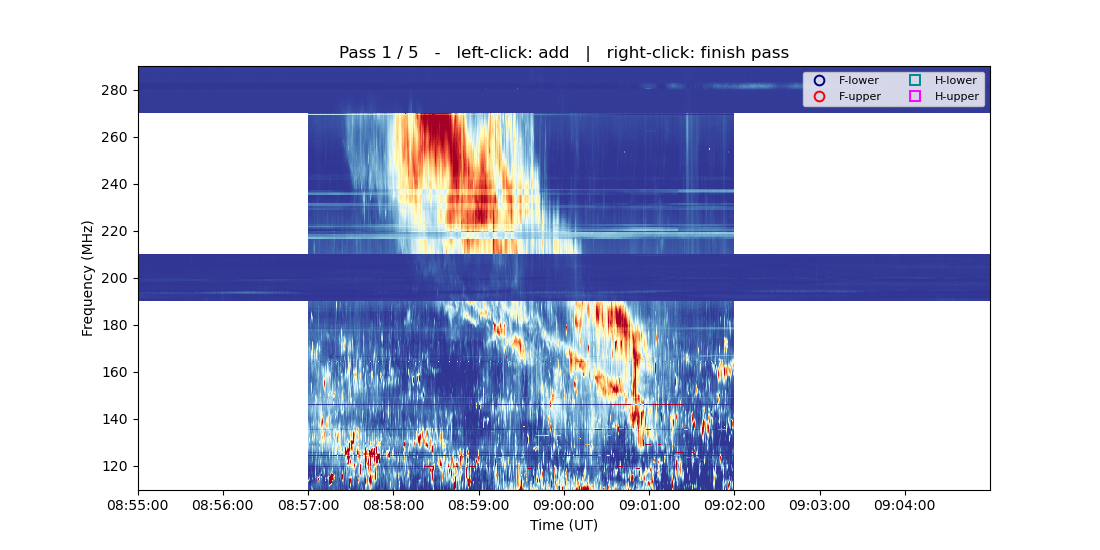

In [42]:
%matplotlib widget
import ipywidgets as widgets
from IPython.display import display

class TypeIIPicker:
    LANES = [('F', 'lower'), ('F', 'upper'), ('H', 'lower'), ('H', 'upper')]
    STYLE = {('F', 'lower'): ('navy', 'o'), ('F', 'upper'): ('red', 'o'),
             ('H', 'lower'): ('darkcyan', 's'), ('H', 'upper'): ('magenta', 's')}

    def __init__(self, layers, n_passes=5, flim=[110, 290], normalise=None):
        self.layers = layers
        self.n_passes = n_passes
        self.flim = flim
        self.normalise = normalise
        self.passes = []
        self.current = self._empty()
        self.active = ('F', 'lower')
        self._build()

    def _empty(self):
        return {b: {ln: {'t': [], 'f': []} for ln in ('lower', 'upper')}
                for b in ('F', 'H')}

    def _build(self):
        self.fig, self.ax = plt.subplots(figsize=[11, 5.5])
        try:
            self.fig.canvas.header_visible = False
        except Exception:
            pass
        draw_layers(self.ax, normalise=self.normalise)
        self.ax.set_ylim(*self.flim)
        self.ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))
        self.ax.set_xlabel('Time (UT)')
        self.ax.set_ylabel('Frequency (MHz)')
        self.scat = {}
        for lane in self.LANES:
            c, m = self.STYLE[lane]
            (self.scat[lane],) = self.ax.plot([], [], m, color=c, ms=7, mew=1.4,
                                              mfc='none', label=f'{lane[0]}-{lane[1]}')
        (self.ghost,) = self.ax.plot([], [], '.', color='0.5', ms=3, alpha=0.4)
        self.ax.legend(loc='upper right', fontsize=8, ncol=2)
        self._title()
        self.sel = widgets.ToggleButtons(
            options=[f'{b}-{l}' for b, l in self.LANES], value='F-lower',
            description='Lane:')
        self.undo_btn    = widgets.Button(description='Undo', icon='rotate-left')
        self.newpass_btn = widgets.Button(description='Finish pass', icon='check',
                                          button_style='success')
        self.status = widgets.HTML()
        self.sel.observe(self._on_sel, names='value')
        self.undo_btn.on_click(lambda _: self._undo())
        self.newpass_btn.on_click(lambda _: self._finish_pass())
        self.fig.canvas.mpl_connect('button_press_event', self._on_click)
        display(widgets.VBox([widgets.HBox([self.sel, self.undo_btn, self.newpass_btn]),
                              self.status]))
        self._update_status()

    def _title(self):
        self.ax.set_title(f'Pass {len(self.passes) + 1} / {self.n_passes}   '
                          f'-   left-click: add   |   right-click: finish pass')

    def _on_sel(self, change):
        b, l = change['new'].split('-')
        self.active = (b, l)

    def _on_click(self, event):
        if event.inaxes != self.ax or event.xdata is None:
            return
        if event.button == 3:                       # right-click resets the pass
            self._finish_pass()
            return
        if len(self.passes) >= self.n_passes:
            self._update_status('All passes recorded.')
            return
        t = mdates.num2date(event.xdata).replace(tzinfo=None)
        b, l = self.active
        self.current[b][l]['t'].append(pd.Timestamp(t))
        self.current[b][l]['f'].append(float(event.ydata))
        self._redraw()
        self._update_status()

    def _redraw(self):
        for lane in self.LANES:
            d = self.current[lane[0]][lane[1]]
            x = mdates.date2num(pd.to_datetime(d['t'])) if d['t'] else []
            self.scat[lane].set_data(x, d['f'] if d['f'] else [])
        self.fig.canvas.draw_idle()

    def _undo(self):
        b, l = self.active
        d = self.current[b][l]
        if d['t']:
            d['t'].pop()
            d['f'].pop()
            self._redraw()
            self._update_status()

    def _finish_pass(self):
        if len(self.passes) >= self.n_passes:
            return
        total = sum(len(self.current[b][l]['f'])
                    for b in ('F', 'H') for l in ('lower', 'upper'))
        if total == 0:
            self._update_status('Nothing traced yet.')
            return
        self.passes.append(self.current)
        gx, gy = [], []
        for pas in self.passes:
            for b in ('F', 'H'):
                for l in ('lower', 'upper'):
                    gx += list(mdates.date2num(pd.to_datetime(pas[b][l]['t'])))
                    gy += list(pas[b][l]['f'])
        self.ghost.set_data(gx, gy)
        self.current = self._empty()
        for lane in self.LANES:
            self.scat[lane].set_data([], [])
        self._title()
        self.fig.canvas.draw_idle()
        self._update_status()

    def _update_status(self, msg=''):
        counts = ' | '.join(f'{b}-{l}:{len(self.current[b][l]["f"])}'
                            for b in ('F', 'H') for l in ('lower', 'upper'))
        self.status.value = (f'<b>Recorded passes:</b> {len(self.passes)}/'
                             f'{self.n_passes} &nbsp; <b>current:</b> {counts} '
                             f'&nbsp; <span style="color:#a00">{msg}</span>')

picker = TypeIIPicker(layers, n_passes=N_PASSES)

## 5. Collect the traced passes

In [43]:
# picks come straight from the picker above (real clicks on the loaded spectra),
# or from a previously saved pickle. No synthetic data.
USE_SAVED_PICKS = False        # True -> reload a previously pickled set of picks

if USE_SAVED_PICKS:
    passes = pickle.load(open(f'{OUTDIR}/type2_picks.pkl', 'rb'))
    print(f'Loaded {len(passes)} passes from {OUTDIR}/type2_picks.pkl')
else:
    passes = picker.passes
    if len(passes) < 1:
        raise RuntimeError('No lanes traced yet. Go to the picker cell, trace the '
                           'type II band(s), and right-click (or "Finish pass") to '
                           'record each pass, then re-run this cell.')
    print(f'Using {len(passes)} traced pass(es) from the picker.')

Using 3 traced pass(es) from the picker.


## 6. Density jump, instantaneous bandwidth, height and shock kinematics

In [44]:
t0 = EVENT_START                         # shared time origin for all passes
HARM = {'F': 1, 'H': 2}                   # harmonic number per band

def _lane_fit(lane, deg=2):
    t = pd.to_datetime(lane['t'])
    f = np.asarray(lane['f'], float)
    if len(f) < 2:
        return None
    ts = (t - t0).total_seconds().to_numpy()
    o = np.argsort(ts)
    ts, f = ts[o], f[o]
    p = np.polyfit(ts, f, min(deg, len(ts) - 1))
    return {'p': p, 'tmin': ts.min(), 'tmax': ts.max()}

def _eval(fit, tg):
    if fit is None:
        return np.full_like(tg, np.nan)
    f = np.polyval(fit['p'], tg)
    f[(tg < fit['tmin']) | (tg > fit['tmax'])] = np.nan
    return f

def build_grid(passes, n=40):
    secs = []
    for pas in passes:
        for b in ('F', 'H'):
            for l in ('lower', 'upper'):
                L = pas[b][l]
                if L['f']:
                    secs += list((pd.to_datetime(L['t']) - t0).total_seconds())
    secs = np.asarray(secs, float)
    return np.linspace(np.nanmin(secs), np.nanmax(secs), n)

def pass_series(pas, tg, model, mu=MU):
    Xs, rs, nes, BW = [], [], [], {}
    for b in ('F', 'H'):
        fl = _eval(_lane_fit(pas[b]['lower']), tg)
        fu = _eval(_lane_fit(pas[b]['upper']), tg)
        with np.errstate(all='ignore'):
            Xs.append((fu / fl) ** 2)
        s = HARM[b]
        rb = np.atleast_1d(freq_to_radius(fl * 1e6, model, harmonic=s)).astype(float)
        rs.append(rb)
        nes.append(freq_to_density(fl * 1e6, harmonic=s))
        BW[b] = fu - fl                                     # instantaneous bandwidth (MHz)
    X  = np.nanmean(np.vstack(Xs),  axis=0)
    r  = np.nanmean(np.vstack(rs),  axis=0)
    ne = np.nanmean(np.vstack(nes), axis=0)
    MA = alfven_mach_from_X(X)
    v = np.full_like(tg, np.nan)
    a = np.full_like(tg, np.nan)
    good = np.isfinite(r)
    if good.sum() > 3:
        pr = np.polyfit(tg[good], r[good], min(3, good.sum() - 1))
        v = np.polyval(np.polyder(pr, 1), tg) * R_SUN_M / 1e3     # km/s
        a = np.polyval(np.polyder(pr, 2), tg) * R_SUN_M / 1e3     # km/s^2
    vA  = v / MA                                                  # km/s
    rho = mu * m_p * (ne * 1e6)                                   # kg/m^3
    B   = (vA * 1e3) * np.sqrt(mu_0 * rho) * 1e4                  # Gauss
    return dict(X=X, r=r, ne=ne, MA=MA, v=v, a=a, vA=vA, B=B,
                BW_F=BW['F'], BW_H=BW['H'])

def aggregate(passes, tg, model, keys=('r', 'v', 'a', 'B', 'X', 'MA', 'vA')):
    stacks = {k: [] for k in keys}
    for pas in passes:
        s = pass_series(pas, tg, model)
        for k in keys:
            stacks[k].append(s[k])
    out = {}
    n = len(passes)
    for k in keys:
        M = np.vstack(stacks[k])
        out[k + '_mean'] = np.nanmean(M, axis=0)
        cnt = np.sum(np.isfinite(M), axis=0)
        sd  = np.nanstd(M, axis=0, ddof=1) if n > 1 else np.zeros(M.shape[1])
        out[k + '_se'] = sd / np.sqrt(np.maximum(cnt, 1))         # standard error
    return out

def sg_smooth(y, window=9, poly=2):
    y = np.asarray(y, float)
    m = np.isfinite(y)
    if m.sum() < 5:
        return y
    yy = y.copy()
    yy[~m] = np.interp(np.flatnonzero(~m), np.flatnonzero(m), y[m])
    w = min(window, len(yy))
    if w % 2 == 0:
        w -= 1
    if w < poly + 2:
        return yy
    return savgol_filter(yy, w, poly)

tg  = build_grid(passes)
agg = aggregate(passes, tg, MODEL_GRID[REF_MODEL_NAME])
print(f'Reference model: {REF_MODEL_NAME}')
print(f'  X   = {np.nanmean(agg["X_mean"]):.2f} +/- {np.nanmean(agg["X_se"]):.2f}')
print(f'  M_A = {np.nanmean(agg["MA_mean"]):.2f} +/- {np.nanmean(agg["MA_se"]):.2f}')
print(f'  v_sh= {np.nanmean(agg["v_mean"]):.0f} +/- {np.nanmean(agg["v_se"]):.0f} km/s')
print(f'  v_A = {np.nanmean(agg["vA_mean"]):.0f} +/- {np.nanmean(agg["vA_se"]):.0f} km/s')
print(f'  B   = {np.nanmean(agg["B_mean"]):.2f} +/- {np.nanmean(agg["B_se"]):.2f} G')

Reference model: Newkirk x2
  X   = 1.12 +/- nan
  M_A = 1.09 +/- nan
  v_sh= 796 +/- 60 km/s
  v_A = 762 +/- nan km/s
  B   = 4.90 +/- nan G


In [45]:
# band-independent scalars: density jump X, M_A, drift rate and relative bandwidth,
# each as mean +/- standard error across the 5 passes
def scalar_summary(passes):
    Xv, MAv, drift, relbw = [], [], [], []
    for pas in passes:
        fl = _lane_fit(pas['F']['lower'])
        fu = _lane_fit(pas['F']['upper'])
        if fl and fu:
            lo = max(fl['tmin'], fu['tmin'])
            hi = min(fl['tmax'], fu['tmax'])
            gg = np.linspace(lo, hi, 20)
            fL = np.polyval(fl['p'], gg)
            fU = np.polyval(fu['p'], gg)
            Xg = (fU / fL) ** 2
            Xv.append(np.nanmean(Xg))
            MAv.append(np.nanmean(alfven_mach_from_X(Xg)))
            relbw.append(np.nanmean((fU - fL) / fL))
        if fl:
            gg = np.linspace(fl['tmin'], fl['tmax'], 20)
            drift.append(np.nanmean(np.polyval(np.polyder(fl['p']), gg)))   # MHz/s
    def mse(arr):
        arr = np.asarray(arr, float)
        se = np.nanstd(arr, ddof=1) / np.sqrt(len(arr)) if len(arr) > 1 else 0.0
        return np.nanmean(arr), se
    return {'X': mse(Xv), 'M_A': mse(MAv), 'drift_MHz_s': mse(drift),
            'rel_bandwidth': mse(relbw)}

scalars = scalar_summary(passes)
for k, (m, e) in scalars.items():
    print(f'{k:16s} = {m:8.3f} +/- {e:.3f}')

X                =      nan +/- 0.000
M_A              =      nan +/- 0.000
drift_MHz_s      =   -0.760 +/- 0.000
rel_bandwidth    =      nan +/- 0.000


## 7. Four-panel figure: kinematics + coronal magnetic field

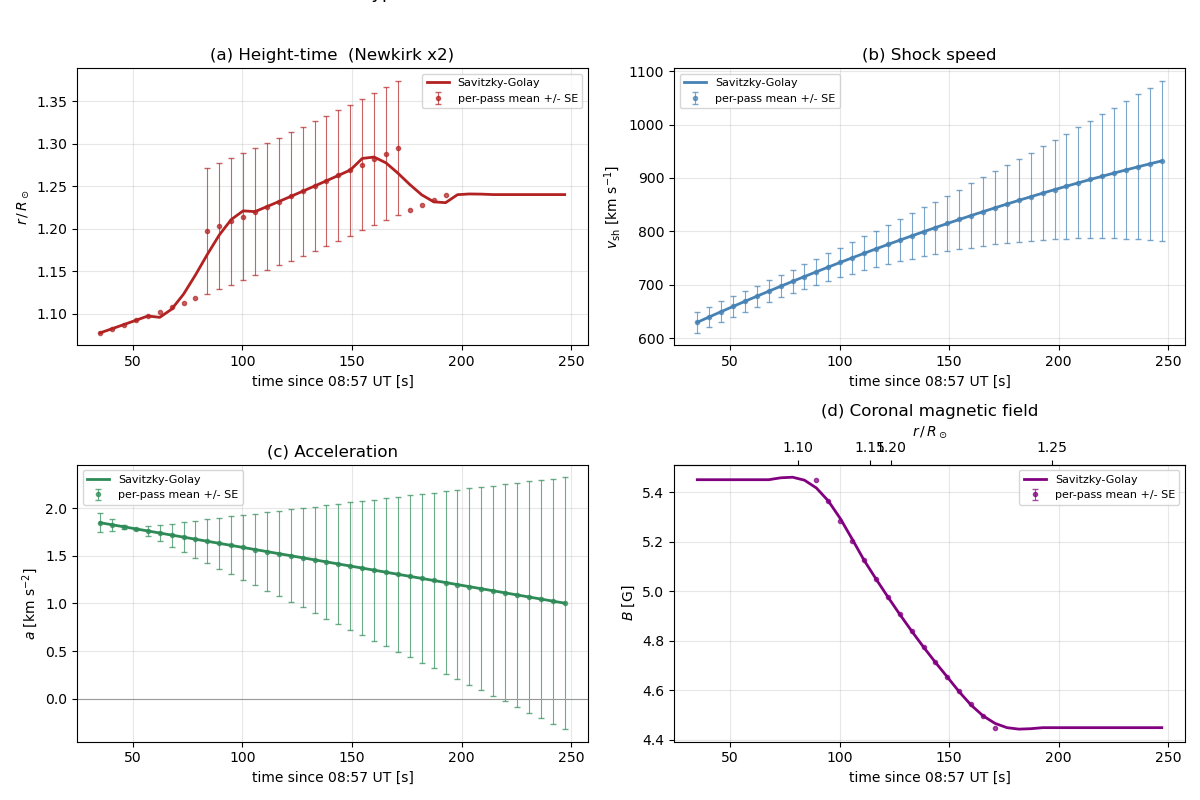

In [46]:
model = MODEL_GRID[REF_MODEL_NAME]
A     = aggregate(passes, tg, model)

fig, axs = plt.subplots(2, 2, figsize=[12, 8])
(axr, axv), (axa, axb) = axs

def panel(ax, key, ylabel, color):
    m, e = A[key + '_mean'], A[key + '_se']
    ax.errorbar(tg, m, yerr=e, fmt='o', ms=3, color=color, ecolor=color,
                elinewidth=0.8, capsize=2, alpha=0.7, label='per-pass mean +/- SE')
    ax.plot(tg, sg_smooth(m), '-', color=color, lw=2, label='Savitzky-Golay')
    ax.set_ylabel(ylabel)
    ax.set_xlabel('time since 08:57 UT [s]')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

# (a) height vs time
panel(axr, 'r', r'$r\,/\,R_\odot$', 'firebrick')
axr.set_title(f'(a) Height-time  ({REF_MODEL_NAME})')

# (b) speed vs time
panel(axv, 'v', r'$v_{\rm sh}$ [km s$^{-1}$]', 'steelblue')
axv.set_title('(b) Shock speed')

# (c) acceleration vs time
panel(axa, 'a', r'$a$ [km s$^{-2}$]', 'seagreen')
axa.axhline(0, color='0.6', lw=0.8)
axa.set_title('(c) Acceleration')

# (d) B vs time (bottom axis) AND vs height (top axis)
mB, eB = A['B_mean'], A['B_se']
axb.errorbar(tg, mB, yerr=eB, fmt='o', ms=3, color='purple', ecolor='purple',
             elinewidth=0.8, capsize=2, alpha=0.7, label='per-pass mean +/- SE')
axb.plot(tg, sg_smooth(mB), '-', color='purple', lw=2, label='Savitzky-Golay')
axb.set_xlabel('time since 08:57 UT [s]')
axb.set_ylabel(r'$B$ [G]')
axb.set_title('(d) Coronal magnetic field')
axb.grid(alpha=0.3)
axb.legend(fontsize=8)

# secondary top axis: time -> height (height is monotonic outward)
rm = A['r_mean']
ok = np.isfinite(rm)
if ok.sum() > 2:
    rmono = np.maximum.accumulate(rm[ok])
    t_of_r = interp1d(tg[ok], rmono, bounds_error=False, fill_value='extrapolate')
    r_of_t = interp1d(rmono, tg[ok], bounds_error=False, fill_value='extrapolate')
    secax = axb.secondary_xaxis('top', functions=(t_of_r, r_of_t))
    secax.set_xlabel(r'$r\,/\,R_\odot$')

fig.suptitle('Type II shock kinematics and coronal B (2025-10-06)', y=1.02, fontsize=13)
fig.tight_layout()
# fig.savefig(f'{OUTDIR}/type2_kinematics_Bfield.png', dpi=300, bbox_inches='tight')
# fig.savefig(f'{OUTDIR}/type2_kinematics_Bfield.pdf', bbox_inches='tight')
plt.show()

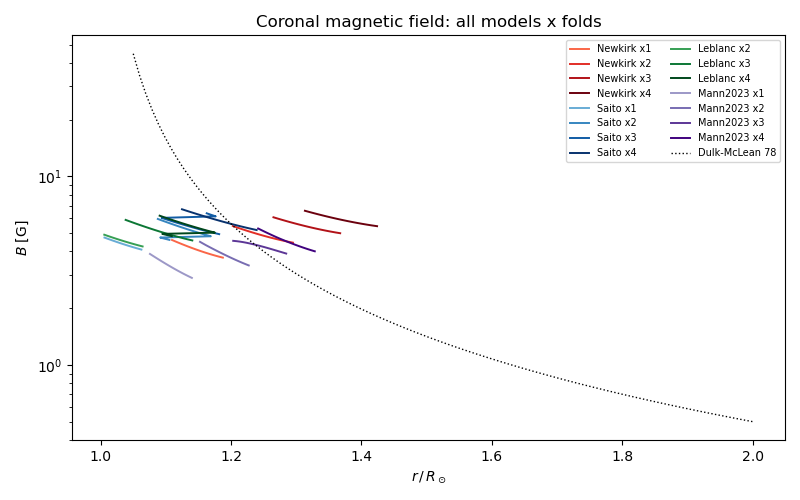

In [47]:
# supplementary: B(r) for every model x fold (16 curves)
fig, ax = plt.subplots(figsize=[8, 5])
cmap = {'Newkirk': plt.cm.Reds, 'Saito': plt.cm.Blues,
        'Leblanc': plt.cm.Greens, 'Mann2023': plt.cm.Purples}
for name, mdl in MODEL_GRID.items():
    base, fold = name.split(' x')
    Ai = aggregate(passes, tg, mdl, keys=('r', 'B'))
    r_i, B_i = Ai['r_mean'], Ai['B_mean']
    good = np.isfinite(r_i) & np.isfinite(B_i)
    if good.sum() > 2:
        ax.plot(r_i[good], B_i[good], color=cmap[base](0.35 + 0.16 * int(fold)),
                lw=1.4, label=name)
rr = np.linspace(1.05, 2.0, 100)
ax.plot(rr, 0.5 * (rr - 1.0) ** (-1.5), 'k:', lw=1, label='Dulk-McLean 78')
ax.set_yscale('log')
ax.set_xlabel(r'$r\,/\,R_\odot$')
ax.set_ylabel(r'$B$ [G]')
ax.set_title('Coronal magnetic field: all models x folds')
ax.legend(fontsize=7, ncol=2, loc='upper right')
fig.tight_layout()
# fig.savefig(f'{OUTDIR}/type2_Bfield_all_models.png', dpi=300, bbox_inches='tight')
# fig.savefig(f'{OUTDIR}/type2_Bfield_all_models.pdf', bbox_inches='tight')
plt.show()

## 8. Export the characteristics table and the raw picks

In [48]:
# per model x fold: grid-averaged height, shock speed, Alfven speed and B (mean +/- SE)
rows = []
for name, mdl in MODEL_GRID.items():
    Ai = aggregate(passes, tg, mdl)
    g  = lambda k: np.nanmean(Ai[k + '_mean'])
    ge = lambda k: np.nanmean(Ai[k + '_se'])
    rows.append({'model_fold': name,
                 'r_Rsun': g('r'),     'r_SE': ge('r'),
                 'v_sh_kms': g('v'),   'v_sh_SE': ge('v'),
                 'vA_kms': g('vA'),    'vA_SE': ge('vA'),
                 'B_G': g('B'),        'B_SE': ge('B')})
table = pd.DataFrame(rows).round(3)

# band-independent scalars as their own small table
scal = pd.DataFrame([{'quantity': k, 'mean': round(m, 3), 'SE': round(e, 3)}
                     for k, (m, e) in scalars.items()])

table.to_csv(f'{OUTDIR}/type2_characteristics.csv', index=False)
scal.to_csv(f'{OUTDIR}/type2_scalars.csv', index=False)

def df_to_latex(df, caption, label):
    # dependency-free LaTeX tabular (avoids pandas' jinja2 requirement)
    cols  = list(df.columns)
    esc   = lambda s: str(s).replace('_', r'\_')
    lines = [r'\begin{table}[ht]', r'\centering',
             r'\caption{' + caption + '}', r'\label{' + label + '}',
             r'\begin{tabular}{l' + 'r' * (len(cols) - 1) + '}', r'\hline',
             ' & '.join(esc(c) for c in cols) + r' \\', r'\hline']
    for _, row in df.iterrows():
        vals = [esc(row[c]) if isinstance(row[c], str) else f'{row[c]:g}' for c in cols]
        lines.append(' & '.join(vals) + r' \\')
    lines += [r'\hline', r'\end{tabular}', r'\end{table}', '']
    return '\n'.join(lines)

with open(f'{OUTDIR}/type2_characteristics.tex', 'w') as fh:
    fh.write(df_to_latex(table,
        'Type II burst shock and coronal magnetic-field diagnostics for 2025-10-06, '
        'for every coronal density model at folds 1--4 (grid-averaged, mean $\\pm$ '
        'standard error over 5 tracing passes).', 'tab:type2'))
with open(f'{OUTDIR}/type2_scalars.tex', 'w') as fh:
    fh.write(df_to_latex(scal,
        'Band-independent type II parameters (mean $\\pm$ SE, 5 passes).',
        'tab:type2_scalars'))

pickle.dump(passes, open(f'{OUTDIR}/type2_picks.pkl', 'wb'))

print('Wrote to', OUTDIR)
for f in sorted(os.listdir(OUTDIR)):
    print('  ', f)
table

Wrote to ./type2_outputs
   type2_characteristics.csv
   type2_characteristics.tex
   type2_picks.pkl
   type2_scalars.csv
   type2_scalars.tex


,model_fold,r_Rsun,r_SE,v_sh_kms,v_sh_SE,vA_kms,vA_SE,B_G,B_SE
0,Newkirk x1,1.106,0.064,670.894,43.923,638.774,NaN,4.110,NaN
1,Newkirk x2,1.199,0.076,795.638,60.210,762.129,NaN,4.903,NaN
2,Newkirk x3,1.261,0.084,885.570,73.084,851.613,NaN,5.477,NaN
3,Newkirk x4,1.309,0.091,959.035,84.262,925.023,NaN,5.948,NaN
4,Saito x1,1.034,NaN,794.290,NaN,720.123,NaN,4.639,NaN
5,Saito x2,1.104,0.085,848.324,47.726,809.970,NaN,5.217,NaN
6,Saito x3,1.137,0.090,920.367,40.504,868.237,NaN,5.593,NaN
7,Saito x4,1.154,0.095,972.474,38.473,912.644,NaN,5.879,NaN
8,Leblanc x1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,Leblanc x2,1.035,NaN,824.109,NaN,746.182,NaN,4.806,NaN


### Notes and conventions

- I-LOFAR is downsampled to the ORFEES cadence with `df.resample(...)` (no common
  grid or reindexing). Where the two overlap in frequency, the ORFEES channels are
  dropped and the finer I-LOFAR channels are kept. Both spectra are normalised with a
  single shared [0, 1] scaling.
- The **lower** band of each split is taken as the upstream/ambient plasma, so
  height, $N_e$ and $\rho$ come from $f_L$; the upper band enters only through
  $X=(f_U/f_L)^2$. The fundamental band uses $s{=}1$ and the harmonic band $s{=}2$;
  both should map to the *same* physical height, which is a built-in consistency check.
- Standard errors are computed **across the 5 tracing passes** (SE $=\sigma/\sqrt{5}$),
  propagated point-by-point on the common time grid.
- "Fold" scales the whole $N_e(r)$ profile by 1-4; combined with 4 models this gives
  the 16 rows of the exported table. Edit `REF_MODEL_NAME`, `MU`, `HARM` at the top of
  the analysis to change the reference case.
- To re-run purely from saved picks (no clicking), set `USE_SAVED_PICKS = True` in the
  collection cell. To reload the raw spectra fast, set `ILOFAR_SOURCE = 'pickle'` at
  the top after the first raw read has cached the pickles.